# Assignment 5 - Swiss Equity Strategy

## 1. Research Objective and Configuration

This notebook is now focused on one research question:

> Do short-horizon Swiss equity returns exhibit mean reversion, and does the result depend on the horizon?

We keep the data exploration compact and move most of the notebook into the empirical analysis. The same mean-reversion tests are run for daily, weekly, and monthly grouped returns.

In [1]:
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from scipy import stats

pd.options.display.float_format = "{:,.4f}".format

STUDY_START_DATE = pd.Timestamp("2010-01-01")
GROUPING_PERIODS = ["D", "W", "M"]

BETA_WINDOW_DAYS = 252
MIN_BETA_OBSERVATIONS = 126
MIN_STOCKS_PER_CROSS_SECTION = 30
HML_PORTFOLIO_FRACTION = 0.10
MIN_REALIZED_LEG_COVERAGE = 0.80
MAX_ABS_DAILY_RETURN_ALERT = 0.50

VOL_LOOKBACK_BY_PERIOD = {"D": 252, "W": 52, "M": 12}
MIN_DAYS_BY_PERIOD = {"D": 1, "W": 3, "M": 10}
RESAMPLE_FREQ = {"D": None, "W": "W-FRI", "M": "ME"}
PERIODS_PER_YEAR = {"D": 252, "W": 52, "M": 12}

unknown_periods = set(GROUPING_PERIODS).difference(RESAMPLE_FREQ)
if unknown_periods:
    raise ValueError(f"Unknown grouping periods: {unknown_periods}")

if not 0 < HML_PORTFOLIO_FRACTION <= 0.5:
    raise ValueError("HML_PORTFOLIO_FRACTION must be between 0 and 0.5.")

if not 0 < MIN_REALIZED_LEG_COVERAGE <= 1:
    raise ValueError("MIN_REALIZED_LEG_COVERAGE must be between 0 and 1.")

## 2. Compact Data Setup

We only keep the data checks needed to understand the research sample:

- number of stocks and date range;
- missing values in the key market fields;
- basic JKP factor availability;
- presence matrix, because a stock can only be traded if it is present at the evaluation date.

The raw market panel is reshaped into wide matrices with dates as rows and stock ids as columns.

In [2]:
def find_project_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not find project root with data/ and src/.")


def set_datetime_level(df: pd.DataFrame, level: str = "date") -> pd.DataFrame:
    df = df.copy().sort_index()
    level_number = df.index.names.index(level)
    df.index = df.index.set_levels(pd.to_datetime(df.index.levels[level_number]), level=level_number)
    return df


def market_wide(market_panel: pd.DataFrame, field: str) -> pd.DataFrame:
    df = market_panel[field].unstack("id").sort_index()
    return df.loc[:, pd.Index(df.columns).notna()]


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

market_data = set_datetime_level(pd.read_parquet(DATA_DIR / "market_data.parquet"))
market_data_clean = market_data[~market_data.index.duplicated(keep="last")]

prices = market_wide(market_data_clean, "price")
mktcaps = market_wide(market_data_clean, "mktcap")
liquidity = market_wide(market_data_clean, "liquidity")
sectors = market_wide(market_data_clean, "sector")
active_stock = prices.notna()

market_overview = pd.DataFrame(
    {
        "rows": [len(market_data_clean)],
        "stocks": [prices.shape[1]],
        "start": [prices.index.min()],
        "end": [prices.index.max()],
        "dates": [prices.shape[0]],
    },
    index=["market_data"],
)

active_observations = active_stock.sum().sum()
missing_summary = pd.DataFrame(
    {
        "missing_count": {
            "price": 0,
            "mktcap": (mktcaps.isna() & active_stock).sum().sum(),
            "liquidity": (liquidity.isna() & active_stock).sum().sum(),
            "sector": (sectors.isna() & active_stock).sum().sum(),
        }
    }
)
missing_summary["missing_pct"] = missing_summary["missing_count"] / active_observations

sector_observations = sectors.stack().dropna().rename("sector")
sector_summary = pd.Series(
    {
        "sector_rows": len(sector_observations),
        "sector_dates": sector_observations.index.get_level_values("date").nunique(),
        "stocks_with_sector": sector_observations.index.get_level_values("id").nunique(),
    }
).to_frame("value")

display(market_overview)
display(missing_summary)
display(sector_summary)

,rows,stocks,start,end,dates
market_data,1399476,313,1985-12-31,2024-04-30,9979


,missing_count,missing_pct
price,0,0.0000
mktcap,0,0.0000
liquidity,102574,0.0738
sector,1388380,0.9984


,value
sector_rows,2253
sector_dates,137
stocks_with_sector,275


In [3]:
jkp_data = set_datetime_level(pd.read_parquet(DATA_DIR / "jkp_data.parquet"))
jkp_data_clean = jkp_data[~jkp_data.index.duplicated(keep="last")]

principal_factors = {
    "Momentum (ret_12_1)": "ret_12_1",
    "Value (be_me)": "be_me",
    "Profitability (qmj_prof)": "qmj_prof",
    "Quality (qmj)": "qmj",
    "Investment (inv_gr1)": "inv_gr1",
}
available_factors = {name: col for name, col in principal_factors.items() if col in jkp_data_clean.columns}
factor_wide = {name: jkp_data_clean[col].unstack("id").sort_index() for name, col in available_factors.items()}

factor_counts = pd.DataFrame({name: df.notna().sum(axis=1) for name, df in factor_wide.items()})
all_factor_mask = None
for df in factor_wide.values():
    all_factor_mask = df.notna() if all_factor_mask is None else (all_factor_mask & df.notna())
factor_counts["All selected factors"] = all_factor_mask.sum(axis=1)

first_factor_dates = pd.Series(
    {
        f"first_date_with_{threshold}_stocks_all_selected_factors": factor_counts.index[factor_counts["All selected factors"] >= threshold].min()
        for threshold in [50, 100, 150]
    }
)

display(factor_counts.describe())
display(first_factor_dates.to_frame("date"))

,Momentum (ret_12_1),Value (be_me),Profitability (qmj_prof),Quality (qmj),Investment (inv_gr1),All selected factors
count,460.0000,460.0000,460.0000,460.0000,460.0000,460.0000
mean,146.9761,134.4935,126.1870,100.0326,96.5630,70.1674
std,58.0516,63.8409,66.1055,65.8418,47.2913,45.5192
min,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
25%,121.7500,96.0000,77.7500,53.7500,68.0000,40.5000
50%,175.0000,171.0000,162.0000,135.0000,122.0000,100.0000
75%,186.2500,176.0000,174.0000,159.0000,129.0000,110.0000
max,206.0000,193.0000,190.0000,170.0000,139.0000,120.0000


,date
first_date_with_50_stocks_all_selected_factors,1998-05-31
first_date_with_100_stocks_all_selected_factors,2003-09-30
first_date_with_150_stocks_all_selected_factors,NaT


## 3. Daily Returns, Beta Neutralization, and Presence

Daily stock returns are computed directly from prices without filling missing observations:

$$
r_{i,d} = \frac{P_{i,d}}{P_{i,d-1}} - 1
$$

The SPI file already contains daily SPI returns, so it is loaded as a return series.

For residual/market-neutral returns, we estimate a rolling beta using only past information:

$$
\beta_{i,d-1} =
\frac{\operatorname{Cov}(r_{i,\tau}, r_{m,\tau})}{\operatorname{Var}(r_{m,\tau})}
$$

and compute:

$$
r^{mn}_{i,d} = r_{i,d} - \beta_{i,d-1}r_{m,d}
$$

Presence is also kept daily. Later, for each grouped period, a stock is tradable only if it is present at the period evaluation date.

In [4]:
def load_spi_returns(path: Path) -> pd.Series:
    spi = pd.read_csv(path / "spi_index.csv", index_col=0, header=0, parse_dates=True, date_format="%d/%m/%Y").squeeze("columns")
    spi.index = pd.DatetimeIndex(spi.index)
    spi.name = "spi_return"
    return spi.sort_index()


daily_stock_returns = prices.pct_change(fill_method=None)
daily_spi_returns = load_spi_returns(DATA_DIR).reindex(daily_stock_returns.index)

rolling_cov = daily_stock_returns.rolling(BETA_WINDOW_DAYS, min_periods=MIN_BETA_OBSERVATIONS).cov(daily_spi_returns)
rolling_var = daily_spi_returns.rolling(BETA_WINDOW_DAYS, min_periods=MIN_BETA_OBSERVATIONS).var()
rolling_beta_lagged = rolling_cov.divide(rolling_var, axis=0).shift(1)
daily_market_neutral_returns = daily_stock_returns - rolling_beta_lagged.multiply(daily_spi_returns, axis=0)

daily_return_values = daily_stock_returns.stack()
return_sanity = pd.Series(
    {
        "daily_stock_return_count": daily_return_values.count(),
        "daily_stock_return_min": daily_return_values.min(),
        "daily_stock_return_max": daily_return_values.max(),
        "daily_stock_abs_return_gt_alert": (daily_return_values.abs() > MAX_ABS_DAILY_RETURN_ALERT).sum(),
        "daily_spi_return_min": daily_spi_returns.min(),
        "daily_spi_return_max": daily_spi_returns.max(),
    }
)

display(return_sanity.to_frame("value"))

,value
daily_stock_return_count,"1,335,432.0000"
daily_stock_return_min,-0.9477
daily_stock_return_max,9.1818
daily_stock_abs_return_gt_alert,153.0000
daily_spi_return_min,-0.0911
daily_spi_return_max,0.1058


## 4. Mean-Reversion Methodology

For each horizon `t` in `D`, `W`, and `M`, daily returns are grouped as:

$$
r_{i,t} = \prod_{d\in t}(1+r_{i,d}) - 1
$$

The tradable universe is:

$$
\mathcal{U}_t = \{i : P^{eval}_{i,t} \text{ is available}\}
$$

A signal is used only if the stock is in this universe:

$$
\tilde{s}_{i,t} =
\begin{cases}
s_{i,t}, & i \in \mathcal{U}_t \\
\text{NaN}, & i \notin \mathcal{U}_t
\end{cases}
$$

We test three mean-reversion signals:

$$
s^{raw}_{i,t} = -r_{i,t}
$$

$$
s^{vol}_{i,t} = -\frac{r_{i,t}}{\sigma_{i,t}}
$$

$$
s^{res}_{i,t} = -\frac{r^{mn}_{i,t}}{\sigma^{mn}_{i,t}}
$$

The first two are evaluated against next-period raw returns. The residual signal is evaluated against next-period market-neutral returns in IC/regression diagnostics. HML portfolio PnL is always computed using raw stock returns because those are the tradable returns.

In [5]:
def aggregate_returns(daily_returns: pd.DataFrame | pd.Series, grouping_period: str, min_days: int):
    freq = RESAMPLE_FREQ[grouping_period]
    if freq is None:
        return daily_returns.copy()
    return (1 + daily_returns).resample(freq).prod(min_count=min_days) - 1


def aggregate_presence(daily_presence: pd.DataFrame, grouping_period: str) -> pd.DataFrame:
    freq = RESAMPLE_FREQ[grouping_period]
    if freq is None:
        return daily_presence.copy()
    return daily_presence.resample(freq).last().fillna(False).astype(bool)


def build_period_data(grouping_period: str) -> dict:
    min_days = MIN_DAYS_BY_PERIOD[grouping_period]
    stock_returns = aggregate_returns(daily_stock_returns, grouping_period, min_days)
    market_neutral_returns = aggregate_returns(daily_market_neutral_returns, grouping_period, min_days)
    spi_returns = aggregate_returns(daily_spi_returns, grouping_period, min_days)
    presence = aggregate_presence(active_stock, grouping_period).reindex(index=stock_returns.index, columns=stock_returns.columns).fillna(False).astype(bool)

    vol_lookback = VOL_LOOKBACK_BY_PERIOD[grouping_period]
    min_vol_periods = max(3, vol_lookback // 2)
    raw_volatility = stock_returns.rolling(vol_lookback, min_periods=min_vol_periods).std()
    residual_volatility = market_neutral_returns.rolling(vol_lookback, min_periods=min_vol_periods).std()

    tradable_at_signal = presence.reindex(index=stock_returns.index, columns=stock_returns.columns).fillna(False).astype(bool)
    target_raw = stock_returns.shift(-1)
    target_residual = market_neutral_returns.shift(-1)

    signals = {
        "Raw mean reversion": ((-stock_returns).where(tradable_at_signal), target_raw),
        "Vol-scaled mean reversion": ((-stock_returns / raw_volatility).where(tradable_at_signal), target_raw),
        "Residual mean reversion": ((-market_neutral_returns / residual_volatility).where(tradable_at_signal), target_residual),
    }

    coverage = pd.DataFrame(
        {
            "present_at_evaluation": presence.sum(axis=1),
            "raw_returns": stock_returns.notna().sum(axis=1),
            "market_neutral_returns": market_neutral_returns.notna().sum(axis=1),
            "raw_and_present": (stock_returns.notna() & presence).sum(axis=1),
            "mn_and_present": (market_neutral_returns.notna() & presence).sum(axis=1),
        }
    )

    return {
        "period": grouping_period,
        "stock_returns": stock_returns,
        "market_neutral_returns": market_neutral_returns,
        "spi_returns": spi_returns,
        "presence": presence,
        "signals": signals,
        "coverage": coverage,
    }

## 5. Evaluation Tests

### 5.1 Information Coefficient

For each date:

$$
IC_t = \rho_S(s_{i,t}, y_{i,t+1})
$$

where $\rho_S$ is the Spearman rank correlation.

### 5.2 Cross-Sectional Regression

Each period we estimate:

$$
y_{i,t+1} = a_t + b_t s_{i,t} + u_{i,t+1}
$$

### 5.3 HML Portfolio

At date `t`, long the top `q` stocks by mean-reversion signal and short the bottom `q`.

We normalize the HML portfolio to **gross exposure 1**:

$$
\sum_i |w_{i,t}| = 1,
\qquad
\sum_{i\in L_t} w_{i,t}=0.5,
\qquad
\sum_{i\in S_t} w_{i,t}=-0.5
$$

Therefore the HML return is:

$$
R^{HML}_{t+1} =
\frac{0.5}{|L_t|}\sum_{i\in L_t} r_{i,t+1}
-
\frac{0.5}{|S_t|}\sum_{i\in S_t} r_{i,t+1}
$$

Turnover is measured as traded notional:

$$
\text{turnover}_t = \sum_i |w_{i,t} - w_{i,t-1}|
$$

With this convention, transaction costs can be applied directly as `cost_rate × turnover`.

Stocks are ranked using only the signal and presence information available at `t`. Next-period returns are used only after portfolio formation.

### 5.4 SPI Exposure

Finally:

$$
R^{HML}_{t} = \alpha + \beta R^{SPI}_{t} + \epsilon_t
$$

In [6]:
def signal_target_frame(signal: pd.DataFrame, target: pd.DataFrame, date) -> pd.DataFrame:
    return pd.concat({"signal": signal.loc[date], "target": target.loc[date]}, axis=1).replace([np.inf, -np.inf], np.nan).dropna()


def study_dates(signal: pd.DataFrame, target: pd.DataFrame):
    dates = signal.index.intersection(target.index)
    return dates[dates >= STUDY_START_DATE]


def ic_summary(signal: pd.DataFrame, target: pd.DataFrame, min_stocks: int = MIN_STOCKS_PER_CROSS_SECTION) -> tuple[pd.Series, dict]:
    ics = {}
    for date in study_dates(signal, target):
        df = signal_target_frame(signal, target, date)
        if len(df) >= min_stocks and df["signal"].nunique() > 1 and df["target"].nunique() > 1:
            ics[date] = stats.spearmanr(df["signal"], df["target"]).statistic

    ic = pd.Series(ics, name="IC").dropna()
    test = stats.ttest_1samp(ic, 0, nan_policy="omit") if len(ic) else None
    return ic, {
        "mean_ic": ic.mean(),
        "ic_tstat": test.statistic if test else np.nan,
        "ic_pvalue": test.pvalue if test else np.nan,
        "ic_hit_rate": (ic > 0).mean() if len(ic) else np.nan,
        "n_periods": len(ic),
    }


def cs_regression_summary(signal: pd.DataFrame, target: pd.DataFrame, min_stocks: int = MIN_STOCKS_PER_CROSS_SECTION) -> dict:
    rows = []
    for date in study_dates(signal, target):
        df = signal_target_frame(signal, target, date)
        if len(df) >= min_stocks and df["signal"].nunique() > 1:
            res = stats.linregress(df["signal"], df["target"])
            rows.append({"date": date, "slope": res.slope, "r2": res.rvalue ** 2})

    out = pd.DataFrame(rows)
    if out.empty:
        return {"avg_slope": np.nan, "slope_tstat": np.nan, "slope_pvalue": np.nan, "avg_r2": np.nan, "n_periods": 0}

    test = stats.ttest_1samp(out["slope"], 0, nan_policy="omit")
    return {"avg_slope": out["slope"].mean(), "slope_tstat": test.statistic, "slope_pvalue": test.pvalue, "avg_r2": out["r2"].mean(), "n_periods": len(out)}


def predictive_study(signals: dict) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    ic_rows = {}
    reg_rows = {}
    ic_series = {}
    for name, (signal, target) in signals.items():
        ic_series[name], ic_rows[name] = ic_summary(signal, target)
        reg_rows[name] = cs_regression_summary(signal, target)
    return pd.DataFrame(ic_rows).T, pd.DataFrame(reg_rows).T, ic_series


def hml_portfolio(signal: pd.DataFrame, pnl_returns: pd.DataFrame, min_stocks: int = MIN_STOCKS_PER_CROSS_SECTION, leg_fraction: float = HML_PORTFOLIO_FRACTION, min_realized_leg_coverage: float = MIN_REALIZED_LEG_COVERAGE) -> tuple[pd.Series, pd.DataFrame, pd.DataFrame]:
    target = pnl_returns.shift(-1)
    returns = {}
    positions = {}
    coverage_rows = []

    for date in study_dates(signal, target):
        signal_row = signal.loc[date].replace([np.inf, -np.inf], np.nan).dropna()
        n_leg = int(np.floor(len(signal_row) * leg_fraction))
        if len(signal_row) < min_stocks or n_leg < 1 or signal_row.nunique() <= 1:
            continue

        ranked = signal_row.sort_values()
        short_ids = ranked.head(n_leg).index
        long_ids = ranked.tail(n_leg).index

        target_row = target.loc[date]
        long_returns = target_row.reindex(long_ids).dropna()
        short_returns = target_row.reindex(short_ids).dropna()
        long_coverage = len(long_returns) / n_leg
        short_coverage = len(short_returns) / n_leg
        coverage_rows.append({"date": date, "n_signal": len(signal_row), "n_leg": n_leg, "long_coverage": long_coverage, "short_coverage": short_coverage})

        if long_coverage < min_realized_leg_coverage or short_coverage < min_realized_leg_coverage:
            continue

        # Gross exposure is 1: +0.5 long book and -0.5 short book.
        returns[date] = 0.5 * long_returns.mean() - 0.5 * short_returns.mean()

        weight = pd.Series(0.0, index=signal.columns)
        weight.loc[long_ids] = 0.5 / n_leg
        weight.loc[short_ids] = -0.5 / n_leg
        positions[date] = weight

    returns = pd.Series(returns, name="hml").dropna()
    positions = pd.DataFrame(positions).T.sort_index()
    coverage = pd.DataFrame(coverage_rows).set_index("date") if coverage_rows else pd.DataFrame()
    return returns, positions, coverage


def portfolio_turnover(positions: pd.DataFrame) -> pd.Series:
    if positions.empty:
        return pd.Series(dtype=float)
    turnover = positions.fillna(0).diff().abs().sum(axis=1)
    turnover.iloc[0] = positions.iloc[0].abs().sum()
    return turnover.rename("turnover")


def max_drawdown(returns: pd.Series) -> float:
    wealth = (1 + returns).cumprod()
    return (wealth / wealth.cummax() - 1).min()


def hml_summary(returns: pd.Series, turnover: pd.Series | None = None, coverage: pd.DataFrame | None = None, grouping_period: str = "M") -> dict:
    if returns.empty:
        return {"avg_period_return": np.nan, "annualized_return": np.nan, "annualized_vol": np.nan, "sharpe": np.nan, "mean_tstat": np.nan, "mean_pvalue": np.nan, "max_drawdown": np.nan, "avg_turnover": np.nan, "avg_long_coverage": np.nan, "avg_short_coverage": np.nan, "n_periods": 0}

    ppy = PERIODS_PER_YEAR[grouping_period]
    test = stats.ttest_1samp(returns, 0, nan_policy="omit")
    ann_vol = returns.std() * np.sqrt(ppy)
    sharpe = returns.mean() / returns.std() * np.sqrt(ppy) if returns.std() != 0 else np.nan
    annualized_return = (1 + returns).prod() ** (ppy / len(returns)) - 1 if (1 + returns).gt(0).all() else np.nan

    return {
        "avg_period_return": returns.mean(),
        "annualized_return": annualized_return,
        "annualized_vol": ann_vol,
        "sharpe": sharpe,
        "mean_tstat": test.statistic,
        "mean_pvalue": test.pvalue,
        "max_drawdown": max_drawdown(returns),
        "avg_turnover": turnover.mean() if turnover is not None and not turnover.empty else np.nan,
        "avg_long_coverage": coverage["long_coverage"].mean() if coverage is not None and not coverage.empty else np.nan,
        "avg_short_coverage": coverage["short_coverage"].mean() if coverage is not None and not coverage.empty else np.nan,
        "n_periods": len(returns),
    }


def hml_study(signals: dict, stock_returns: pd.DataFrame, grouping_period: str) -> tuple[pd.DataFrame, pd.DataFrame, dict, dict]:
    hml_returns = {}
    hml_positions = {}
    hml_coverage = {}
    hml_turnover = {}

    for name, (signal, _) in signals.items():
        returns, positions, coverage = hml_portfolio(signal, stock_returns)
        hml_returns[name] = returns
        hml_positions[name] = positions
        hml_coverage[name] = coverage
        hml_turnover[name] = portfolio_turnover(positions)

    hml_returns_df = pd.DataFrame(hml_returns)
    hml_table = pd.DataFrame({name: hml_summary(hml_returns[name], hml_turnover[name], hml_coverage[name], grouping_period) for name in hml_returns}).T
    return hml_returns_df, hml_table, hml_positions, hml_coverage


def spi_regression_summary(hml_return: pd.Series, spi_return: pd.Series) -> dict:
    df = pd.concat({"hml": hml_return, "spi": spi_return}, axis=1).dropna()
    if len(df) < 3:
        return {"alpha_per_period": np.nan, "alpha_tstat": np.nan, "alpha_pvalue": np.nan, "beta": np.nan, "beta_tstat": np.nan, "beta_pvalue": np.nan, "r2": np.nan, "n_periods": len(df)}

    model = sm.OLS(df["hml"], sm.add_constant(df["spi"])).fit()
    return {"alpha_per_period": model.params["const"], "alpha_tstat": model.tvalues["const"], "alpha_pvalue": model.pvalues["const"], "beta": model.params["spi"], "beta_tstat": model.tvalues["spi"], "beta_pvalue": model.pvalues["spi"], "r2": model.rsquared, "n_periods": int(model.nobs)}


def spi_exposure_study(hml_returns_df: pd.DataFrame, spi_returns: pd.Series) -> pd.DataFrame:
    spi_next = spi_returns.shift(-1)
    return pd.DataFrame({name: spi_regression_summary(hml_returns_df[name], spi_next) for name in hml_returns_df.columns}).T

## 6. Run Mean-Reversion Study for D, W, and M

This is the central section of the notebook. The exact same pipeline is run for each grouping period:

1. group raw, residual, and SPI returns;
2. build the presence-filtered mean-reversion signals;
3. compute IC and cross-sectional regression diagnostics;
4. build HML long-short portfolios;
5. regress HML returns on SPI returns.

In [7]:
def run_mean_reversion_study(grouping_period: str) -> dict:
    data = build_period_data(grouping_period)
    ic_table, regression_table, ic_series = predictive_study(data["signals"])
    hml_returns_df, hml_table, hml_positions, hml_coverage = hml_study(data["signals"], data["stock_returns"], grouping_period)
    spi_regression_table = spi_exposure_study(hml_returns_df, data["spi_returns"])

    return {
        **data,
        "ic_table": ic_table,
        "regression_table": regression_table,
        "ic_series": ic_series,
        "hml_returns": hml_returns_df,
        "hml_table": hml_table,
        "hml_positions": hml_positions,
        "hml_coverage": hml_coverage,
        "spi_regression_table": spi_regression_table,
    }


period_results = {period: run_mean_reversion_study(period) for period in GROUPING_PERIODS}

ic_comparison = pd.concat({period: result["ic_table"] for period, result in period_results.items()}, names=["period", "signal"])
regression_comparison = pd.concat({period: result["regression_table"] for period, result in period_results.items()}, names=["period", "signal"])
hml_comparison = pd.concat({period: result["hml_table"] for period, result in period_results.items()}, names=["period", "signal"])
spi_regression_comparison = pd.concat({period: result["spi_regression_table"] for period, result in period_results.items()}, names=["period", "signal"])

coverage_comparison = pd.DataFrame(
    {
        period: result["coverage"].loc[result["coverage"].index >= STUDY_START_DATE, ["present_at_evaluation", "raw_and_present", "mn_and_present"]].mean()
        for period, result in period_results.items()
    }
).T

print("Mean-reversion IC by horizon")
display(ic_comparison)
print("Cross-sectional regression by horizon")
display(regression_comparison)
print("HML performance by horizon")
display(hml_comparison)
print("SPI exposure by horizon")
display(spi_regression_comparison)
print("Average coverage by horizon")
display(coverage_comparison)

C:\Users\axeli\AppData\Local\Temp\ipykernel_3784\4241987621.py:151: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat({"hml": hml_return, "spi": spi_return}, axis=1).dropna()
C:\Users\axeli\AppData\Local\Temp\ipykernel_3784\4241987621.py:151: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat({"hml": hml_return, "spi": spi_return}, axis=1).dropna()
C:\Users\axeli\AppData\Local\Temp\ipykernel_3784\4241987621.py:151: Pandas4Warning: Sorting by default when concatenating al

Mean-reversion IC by horizon


C:\Users\axeli\AppData\Local\Temp\ipykernel_3784\4241987621.py:151: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat({"hml": hml_return, "spi": spi_return}, axis=1).dropna()
C:\Users\axeli\AppData\Local\Temp\ipykernel_3784\4241987621.py:151: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat({"hml": hml_return, "spi": spi_return}, axis=1).dropna()
C:\Users\axeli\AppData\Local\Temp\ipykernel_3784\4241987621.py:151: Pandas4Warning: Sorting by default when concatenating al

mean_ic  ic_tstat  ic_pvalue  ic_hit_rate  \
period signal                                                                 
D      Raw mean reversion          0.0796   34.4013     0.0000       0.7326   
       Vol-scaled mean reversion   0.0826   38.4704     0.0000       0.7618   
       Residual mean reversion     0.0871   48.0274     0.0000       0.8015   
W      Raw mean reversion          0.0510    9.5863     0.0000       0.6292   
       Vol-scaled mean reversion   0.0548   11.5795     0.0000       0.6493   
       Residual mean reversion     0.0515   12.1890     0.0000       0.6827   
M      Raw mean reversion         -0.0034   -0.3047     0.7610       0.4912   
       Vol-scaled mean reversion  -0.0044   -0.4502     0.6532       0.4737   
       Residual mean reversion    -0.0028   -0.3288     0.7427       0.4503   

                                  n_periods  
period signal                                
D      Raw mean reversion        3,556.0000  
       Vol-scaled mean reversion 3,556.0000  
       Residual mean reversion   3,556.0000  
W      Raw mean reversion          747.0000  
       Vol-scaled mean reversion   747.0000  
       Residual mean reversion     747.0000  
M      Raw mean reversion          171.0000  
       Vol-scaled mean reversion   171.0000  
       Residual mean reversion     171.0000

Cross-sectional regression by horizon


...

avg_period_return  annualized_return  \
period signal                                                            
D      Raw mean reversion                    0.0028             0.9956   
       Vol-scaled mean reversion             0.0027             0.9429   
       Residual mean reversion               0.0026             0.9054   
W      Raw mean reversion                    0.0023             0.1052   
       Vol-scaled mean reversion             0.0034             0.1909   
       Residual mean reversion               0.0031             0.1726   
M      Raw mean reversion                   -0.0038            -0.0682   
       Vol-scaled mean reversion            -0.0043            -0.0705   
       Residual mean reversion              -0.0050            -0.0809   

                                  annualized_vol  sharpe  mean_tstat  \
period signal                                                          
D      Raw mean reversion                 0.1339  5.2327     19.8544   
       Vol-scaled mean reversion          0.0923  7.2548     27.5269   
       Residual mean reversion            0.0916  7.0909     26.9049   
W      Raw mean reversion                 0.1688  0.6951      2.6346   
       Vol-scaled mean reversion          0.0830  2.1486      8.1434   
       Residual mean reversion            0.0840  1.9393      7.3501   
M      Raw mean reversion                 0.1819 -0.2496     -0.9422   
       Vol-scaled mean reversion          0.1670 -0.3108     -1.1733   
       Residual mean reversion            0.1738 -0.3456     -1.3045   

                                  mean_pvalue  max_drawdown  avg_turnover  \
period signal                                                               
D      Raw mean reversion              0.0000       -0.1619        1.7324   
       Vol-scaled mean reversion       0.0000       -0.1551        1.7909   
       Residual mean reversion         0.0000       -0.1167        1.7875   
W      Raw mean reversion              0.0086       -0.4621        1.7114   
       Vol-scaled mean reversion       0.0000       -0.0948        1.7856   
       Residual mean reversion         0.0000       -0.1478        1.7863   
M      Raw mean reversion              0.3474       -0.6965        1.6751   
       Vol-scaled mean reversion       0.2423       -0.7049        1.7524   
       Residual mean reversion         0.1938       -0.7285        1.7632   

                                  avg_long_coverage  avg_short_coverage  \
period signal                                                             
D      Raw mean reversion                    0.9996              0.9996   
       Vol-scaled mean reversion             0.9997              0.9996   
       Residual mean reversion               0.9997              0.9996   
W      Raw mean reversion                    0.9982              0.9985   
       Vol-scaled mean reversion             0.9983              0.9986   
       Residual mean reversion               0.9984              0.9986   
M      Raw mean reversion                    0.9929              0.9935   
       Vol-scaled mean reversion             0.9929              0.9935   
       Residual mean reversion               0.9932              0.9939   

                                  n_periods  
period signal                                
D      Raw mean reversion        3,628.0000  
       Vol-scaled mean reversion 3,628.0000  
       Residual mean reversion   3,628.0000  
W      Raw mean reversion          747.0000  
       Vol-scaled mean reversion   747.0000  
       Residual mean reversion     747.0000  
M      Raw mean reversion          171.0000  
       Vol-scaled mean reversion   171.0000  
       Residual mean reversion     171.0000

SPI exposure by horizon


alpha_per_period  alpha_tstat  alpha_pvalue  \
period signal                                                                   
D      Raw mean reversion                   0.0028      19.7612        0.0000   
       Vol-scaled mean reversion            0.0026      27.4575        0.0000   
       Residual mean reversion              0.0026      26.8287        0.0000   
W      Raw mean reversion                   0.0020       2.3618        0.0184   
       Vol-scaled mean reversion            0.0032       7.8576        0.0000   
       Residual mean reversion              0.0030       7.0775        0.0000   
M      Raw mean reversion                  -0.0062      -1.5603        0.1206   
       Vol-scaled mean reversion           -0.0066      -1.8118        0.0718   
       Residual mean reversion             -0.0074      -1.9385        0.0542   

                                   beta  beta_tstat  beta_pvalue     r2  \
period signal                                                             
D      Raw mean reversion        0.0612      3.9977       0.0001 0.0044   
       Vol-scaled mean reversion 0.0619      5.8880       0.0000 0.0095   
       Residual mean reversion   0.0307      2.9247       0.0035 0.0024   
W      Raw mean reversion        0.1604      3.8339       0.0001 0.0193   
       Vol-scaled mean reversion 0.1188      5.8453       0.0000 0.0439   
       Residual mean reversion   0.0973      4.6926       0.0000 0.0287   
M      Raw mean reversion        0.3792      3.2390       0.0014 0.0585   
       Vol-scaled mean reversion 0.3568      3.3261       0.0011 0.0614   
       Residual mean reversion   0.3686      3.2989       0.0012 0.0605   

                                  n_periods  
period signal                                
D      Raw mean reversion        3,628.0000  
       Vol-scaled mean reversion 3,628.0000  
       Residual mean reversion   3,628.0000  
W      Raw mean reversion          747.0000  
       Vol-scaled mean reversion   747.0000  
       Residual mean reversion     747.0000  
M      Raw mean reversion          171.0000  
       Vol-scaled mean reversion   171.0000  
       Residual mean reversion     171.0000

Average coverage by horizon


,present_at_evaluation,raw_and_present,mn_and_present
D,183.5079,183.4948,181.9778
W,183.5194,183.2296,181.7183
M,183.4884,183.3547,181.8430


## 7. Cumulative HML Returns by Horizon

The tables above are the primary evidence. The plots below help us see whether performance is smooth or dominated by a few tail events.

Remember: these are gross returns before transaction costs, borrow costs, bid-ask spreads, and market impact.

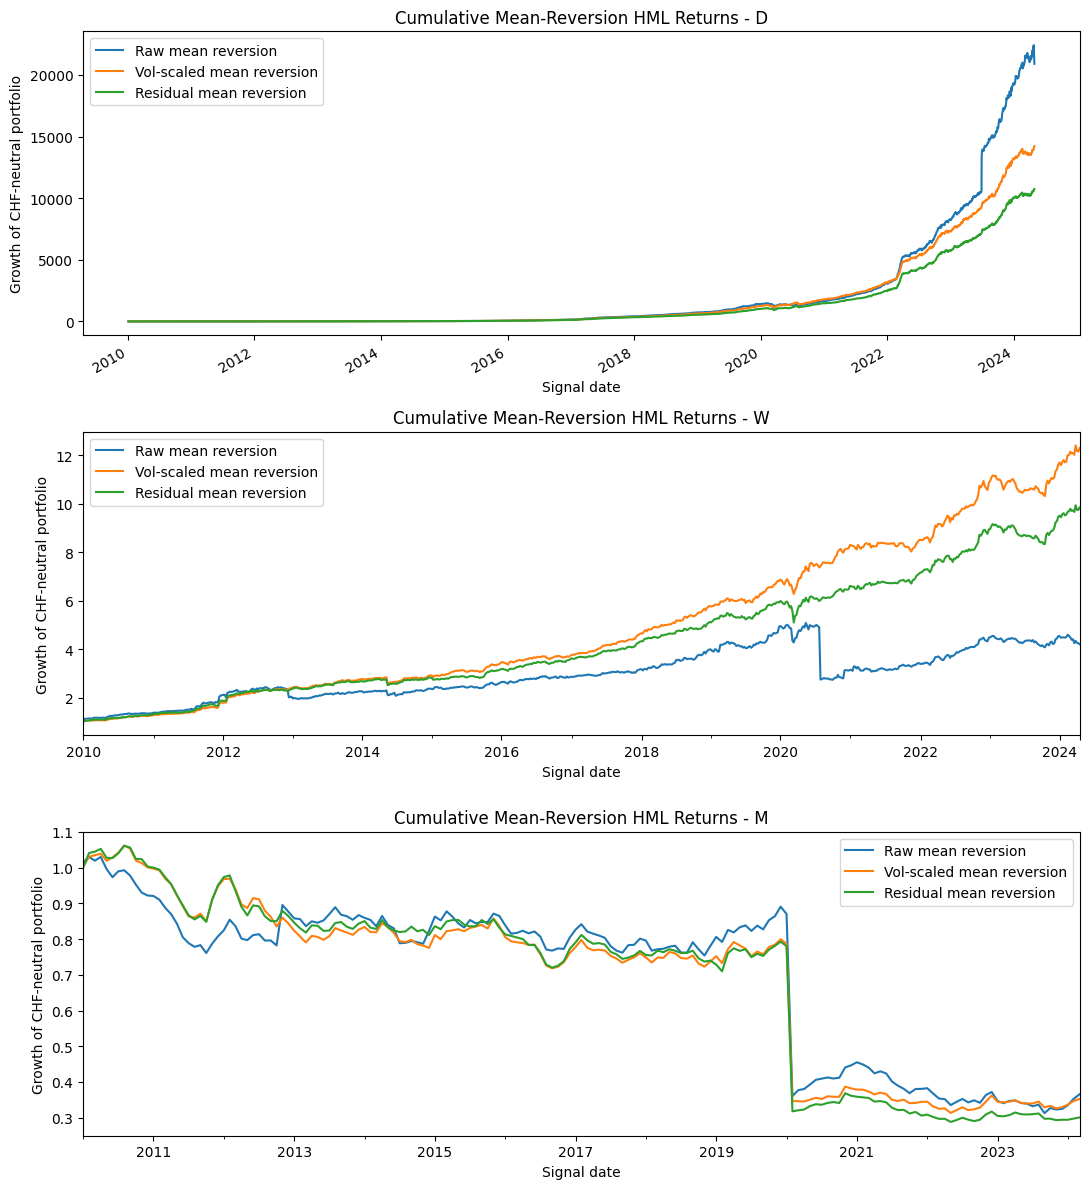

In [8]:
fig, axes = plt.subplots(len(GROUPING_PERIODS), 1, figsize=(11, 4 * len(GROUPING_PERIODS)), sharex=False)
if len(GROUPING_PERIODS) == 1:
    axes = [axes]

for ax, period in zip(axes, GROUPING_PERIODS):
    hml_returns = period_results[period]["hml_returns"]
    (1 + hml_returns).cumprod().plot(ax=ax)
    ax.set_title(f"Cumulative Mean-Reversion HML Returns - {period}")
    ax.set_xlabel("Signal date")
    ax.set_ylabel("Growth of CHF-neutral portfolio")

plt.tight_layout()
plt.show()

## 8. Tail-Event Diagnostics

Short-horizon reversal strategies can look attractive on average but still be fragile. A single short position that rises dramatically can dominate the raw HML portfolio.

The next table lists the worst HML periods for each horizon and signal. This is useful for checking whether results are stable or driven by isolated events.

In [9]:
worst_hml_events = []
for period, result in period_results.items():
    for signal_name in result["hml_returns"].columns:
        worst = result["hml_returns"][signal_name].dropna().nsmallest(5)
        for date, value in worst.items():
            worst_hml_events.append({"period": period, "signal": signal_name, "date": date, "hml_return": value})

worst_hml_events = pd.DataFrame(worst_hml_events).sort_values(["period", "signal", "hml_return"])
display(worst_hml_events)

,period,signal,date,hml_return
0,D,Raw mean reversion,2020-07-06,-0.1086
1,D,Raw mean reversion,2024-04-29,-0.0676
2,D,Raw mean reversion,2012-05-02,-0.0533
3,D,Raw mean reversion,2020-08-05,-0.0521
4,D,Raw mean reversion,2015-03-04,-0.0428
10,D,Residual mean reversion,2015-03-04,-0.0481
11,D,Residual mean reversion,2020-03-10,-0.0357
12,D,Residual mean reversion,2020-02-17,-0.0340
13,D,Residual mean reversion,2020-08-03,-0.0269
14,D,Residual mean reversion,2012-01-25,-0.0254


In [10]:
def hml_event_details(period: str, signal_name: str, date, n: int = 10) -> tuple[pd.DataFrame, pd.DataFrame]:
    result = period_results[period]
    signal = result["signals"][signal_name][0]
    target = result["stock_returns"].shift(-1)

    signal_row = signal.loc[date].replace([np.inf, -np.inf], np.nan).dropna()
    n_leg = int(np.floor(len(signal_row) * HML_PORTFOLIO_FRACTION))
    ranked = signal_row.sort_values()
    short_ids = ranked.head(n_leg).index
    long_ids = ranked.tail(n_leg).index
    target_row = target.loc[date]

    long_leg = pd.DataFrame(
        {
            "signal": signal_row.reindex(long_ids),
            "previous_period_return": -signal_row.reindex(long_ids),
            "next_period_return": target_row.reindex(long_ids),
        }
    ).sort_values("next_period_return")

    short_leg = pd.DataFrame(
        {
            "signal": signal_row.reindex(short_ids),
            "previous_period_return": -signal_row.reindex(short_ids),
            "next_period_return": target_row.reindex(short_ids),
        }
    ).sort_values("next_period_return", ascending=False)

    return long_leg.head(n), short_leg.head(n)


worst_raw_weekly_date = period_results["W"]["hml_returns"]["Raw mean reversion"].dropna().idxmin()
weekly_raw_long_tail, weekly_raw_short_tail = hml_event_details("W", "Raw mean reversion", worst_raw_weekly_date, n=10)

print(f"Worst weekly raw mean-reversion event: {worst_raw_weekly_date.date()}")
print("Long leg tail")
display(weekly_raw_long_tail)
print("Short leg tail")
display(weekly_raw_short_tail)

Worst weekly raw mean-reversion event: 2020-07-31
Long leg tail


,signal,previous_period_return,next_period_return
id,,,
13,0.0647,-0.0647,-0.0755
285,0.0687,-0.0687,-0.0369
100,0.0637,-0.0637,-0.0160
211,0.0586,-0.0586,-0.0133
42,0.0673,-0.0673,-0.0015
27,0.0741,-0.0741,0.0015
148,0.0640,-0.0640,0.0070
170,0.0617,-0.0617,0.0233
233,0.0766,-0.0766,0.0270


Short leg tail


,signal,previous_period_return,next_period_return
id,,,
275,-0.0559,0.0559,16.0588
34,-0.0435,0.0435,0.1333
262,-0.1333,0.1333,0.0739
271,-0.0346,0.0346,0.0595
102,-0.0600,0.0600,0.0533
136,-0.0378,0.0378,0.0421
74,-0.0497,0.0497,0.0336
184,-0.0235,0.0235,0.0203
111,-0.0405,0.0405,0.0190


## 9. Interpretation Checklist

Use the notebook in this order:

1. Check coverage: we need enough tradable stocks at each horizon.
2. Check IC: positive IC means recent losers tend to outperform recent winners next period.
3. Check regression slopes: positive average slope confirms the expected sign in a linear cross-sectional test.
4. Check HML: this translates the signal into a gross long-short portfolio.
5. Check SPI beta: a strong reversal result with high market beta may simply be a market exposure.
6. Check tail events: raw reversal can be fragile when a shorted winner explodes upward.

The key caveat remains: these results are gross of transaction costs. This matters especially for daily and weekly tests because turnover is high.